<a href="https://colab.research.google.com/github/Loki-33/Stuffs/blob/main/10_armed_bandit_Different_exploration_Strats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import torch
import gymnasium as gym
import buffalo_gym

In [17]:
env = gym.make("Buffalo-v0")

In [19]:
obs, _ = env.reset(seed=42)

In [30]:
env.observation_space

Box(0.0, 1.0, (1,), float32)

In [31]:
env.action_space

Discrete(10)

In [32]:
obs, info = env.reset()
print("Obs 1:", obs)

obs, reward, done, truncated, info = env.step(0)
print("Obs 2:", obs)

obs, reward, done, truncated, info = env.step(1)
print("Obs 3:", obs)

Obs 1: [0.]
Obs 2: [0.]
Obs 3: [0.]


In [43]:
import random

In [67]:
def train_step(q_table, eps=0.3, alpha=0.1):
  if random.random() < eps:
    action = env.action_space.sample()
  else:
    action = torch.argmax(q_table).item()
  obs, reward, done, truncated, info = env.step(action)
  q_table[action] += alpha * (reward - q_table[action])
  return q_table, reward, action

In [68]:
def train(num_steps=1000, eps=0.01, alpha=0.1):
  q_table = torch.zeros(10)
  rewards = []
  actions = []
  env.reset(seed=42)
  for step in range(num_steps):
    q_table, reward, action = train_step(q_table, eps, alpha)
    rewards.append(reward)
    actions.append(action)
  return q_table, rewards, actions

In [69]:
q_table, rewards, actions = train()

In [70]:
q_table

tensor([10.1106,  0.4626,  0.3659,  0.3473,  0.7710,  0.4254,  0.2861,  0.0000,
         0.6905,  0.5776])

In [71]:
import matplotlib.pyplot as plt

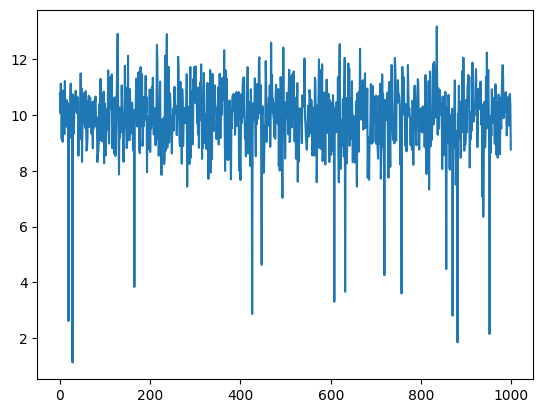

In [72]:
plt.plot(range(1000), rewards)

In [73]:
import numpy as np

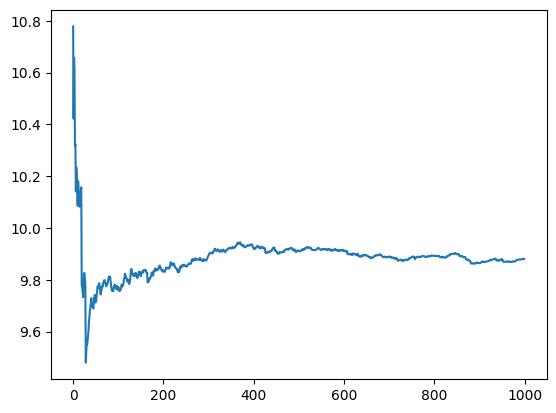

In [74]:
cumulative_avg = np.cumsum(rewards) / np.arange(1, len(rewards)+1)
plt.plot(cumulative_avg)

(array([987.,   1.,   1.,   2.,   2.,   1.,   1.,   0.,   3.,   2.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

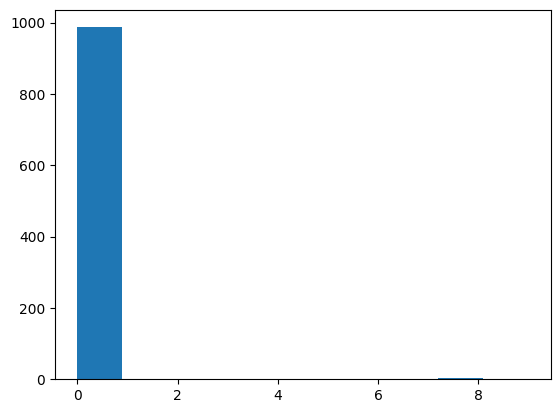

In [75]:
plt.hist(actions, bins=10)

In [88]:
# epsilon-decay
def train_step1(q_table, current_eps, alpha=0.01):
  if random.random() < current_eps:
    action = env.action_space.sample()
  else:
    action = torch.argmax(q_table).item()
  obs, reward, done, truncated, info = env.step(action)
  q_table[action] += alpha * (reward - q_table[action])
  return q_table, reward, action

In [89]:
def train1(num_steps=1000, eps_start=1.0, eps_end=0.01, rate=0.995, alpha=0.01):
  q_table = torch.zeros(10)
  rewards = []
  actions = []
  env.reset(seed=42)
  current_eps = eps_start
  for step in range(num_steps):
    q_table, reward, action = train_step1(q_table, current_eps, alpha)
    rewards.append(reward)
    actions.append(action)
    current_eps = max(eps_end, current_eps * rate)
  return q_table, rewards, actions

In [90]:
q_table1, rewards1, actions1 = train1()

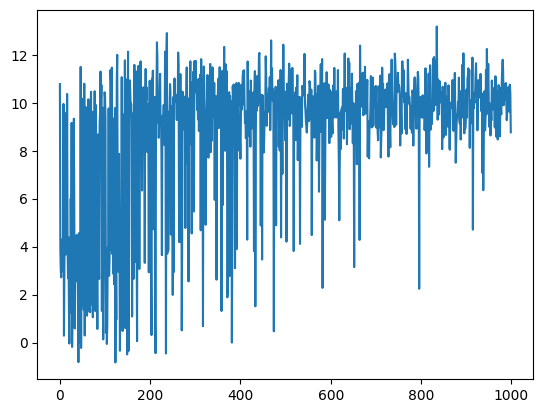

In [91]:
plt.plot(rewards1)

(array([825.,  19.,  24.,  15.,  23.,  22.,  19.,  20.,  23.,  10.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

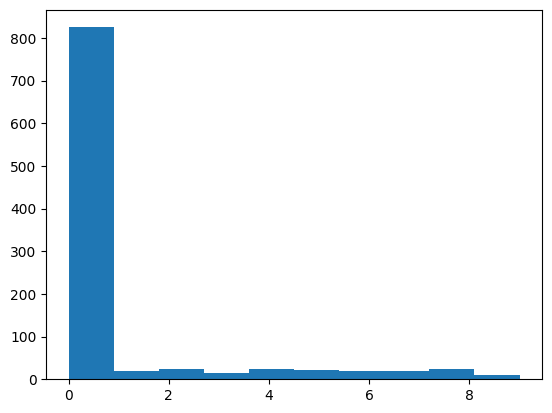

In [92]:
plt.hist(actions1, bins=10)

In [119]:
# UCB with optimistiacally initialization
def train2(c=2):
  q_table = torch.ones(10) * 20
  action_table = torch.ones(10)
  rewards = []
  actions = []
  env.reset(seed=42)
  for step in range(1, 1001):
    action = torch.argmax(q_table + c* torch.sqrt(torch.log(torch.tensor(step)) / action_table)).item()
    obs, reward, done, truncated, info = env.step(action)
    q_table[action] += 0.1 * (reward - q_table[action])
    action_table[action] += 1
    rewards.append(reward)
    actions.append(action)
  return q_table, rewards, actions, action_table

In [120]:
q_table2, rewards2, actions2, action_table2 = train2()

In [121]:
q_table2

tensor([10.1105,  8.0407,  7.9084,  7.5679,  7.9843,  8.0332,  7.8389,  7.3486,
         8.0235,  7.7480])

(array([892.,  13.,  13.,  10.,  15.,  12.,  13.,  10.,  11.,  11.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

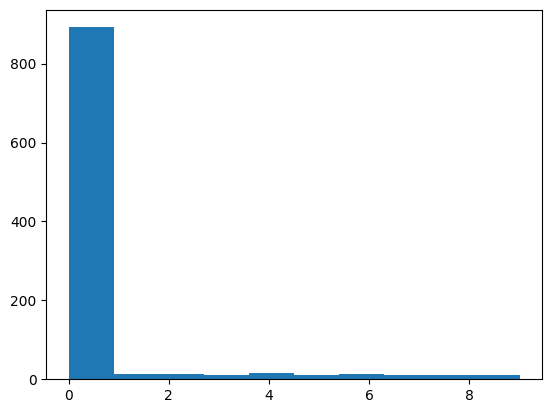

In [122]:
plt.hist(actions2, bins=10)

In [111]:
action_table2

tensor([1.0001e+04, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00])

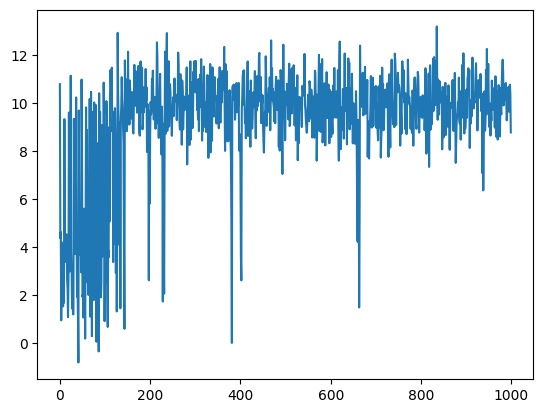

In [149]:
plt.plot(rewards2)

In [123]:
# boltzmann or softmax exploration
def train3(tau=1.0):
  q_table = torch.zeros(10)
  rewards = []
  actions= []

  for step in range(1000):
    probs = torch.exp(q_table / tau) / torch.exp(q_table / tau).sum()
    action = torch.multinomial(probs, 1).item()
    obs, reward, done, truncated, info = env.step(action)
    q_table[action] += 0.1 * (reward - q_table[action])
    rewards.append(reward)
    actions.append(action)
  return q_table, rewards, actions


In [167]:
q_table3, rewards3, actions3 = train3()

(array([783.,  14.,   3.,  12.,  60., 101.,  15.,   6.,   3.,   3.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

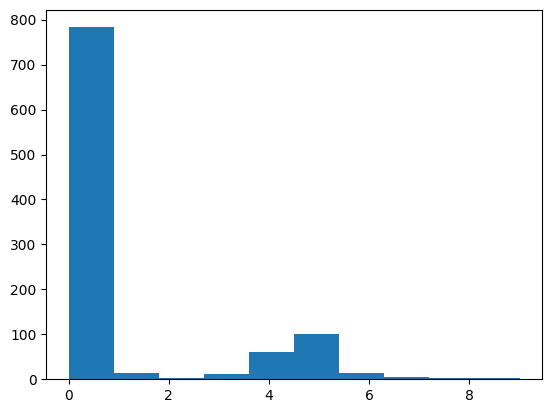

In [125]:
plt.hist(actions3, bins=10)

In [126]:
q_table3, rewards3, actions3 = train3(tau=10)

(array([187., 124.,  83.,  85., 103.,  91.,  84.,  80.,  84.,  79.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

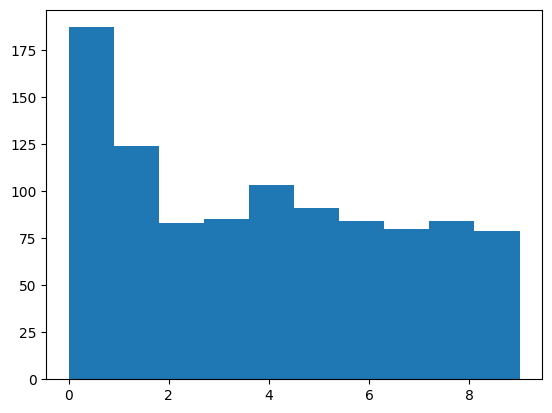

In [129]:
plt.hist(actions3, bins=10)

In [130]:
## thomson sampling

In [144]:
def train4():
  mean = torch.zeros(10)
  M2 = torch.ones(10) * 100
  count = torch.zeros(10)
  rewards = []
  actions = []
  for step in range(1000):
    var = M2 / (count + 1)
    std = torch.sqrt(var + 1e-6)
    probs = torch.distributions.Normal(mean, std).sample()
    action = torch.argmax(probs).item()
    obs, reward, done, truncated, info = env.step(action)
    delta = reward - mean[action]
    count[action] += 1
    mean[action] += delta / count[action]
    M2[action] += delta * (reward - mean[action])

    rewards.append(reward)
    actions.append(action)
  return mean, rewards, actions

In [145]:
mean, rewards4, actions4 = train4()

(array([844.,  25.,  18.,  11.,  26.,  20.,  20.,   8.,  14.,  14.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

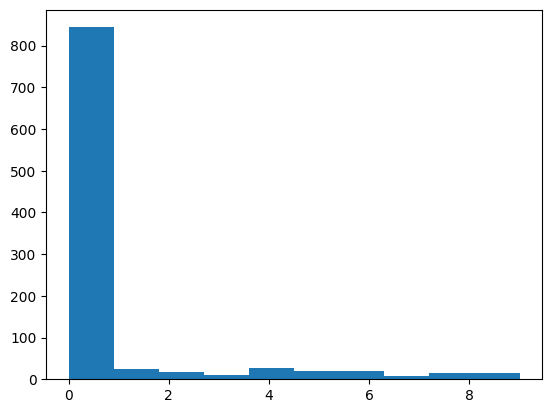

In [146]:
plt.hist(actions4, bins=10)

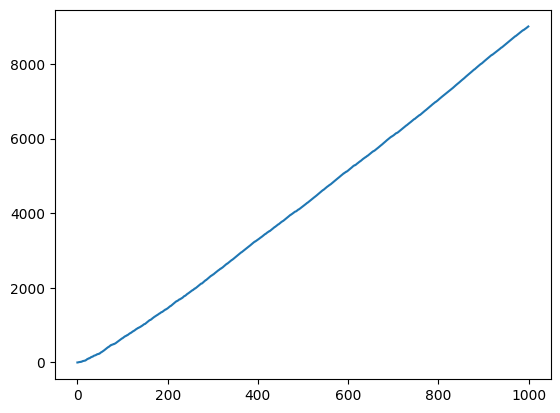

In [147]:
plt.plot(np.cumsum(rewards4))

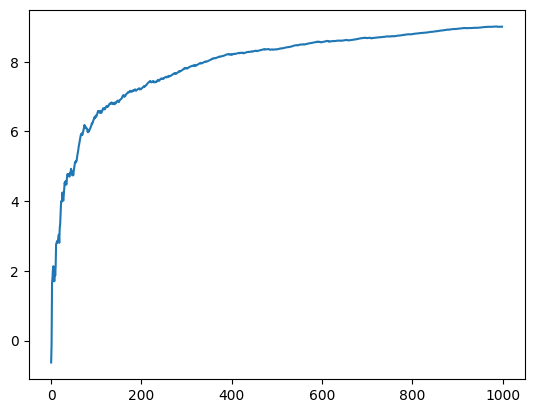

In [148]:
cumulative_avg = np.cumsum(rewards4) / np.arange(1, len(rewards4)+1)
plt.plot(cumulative_avg)

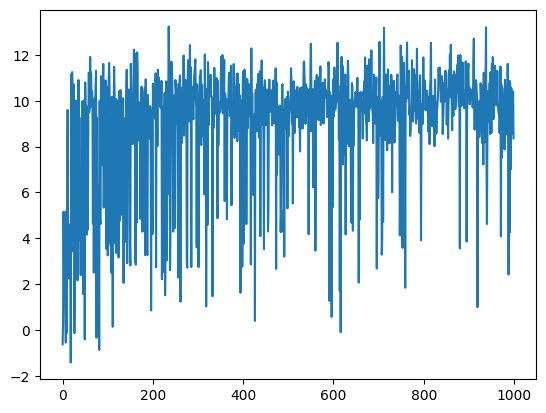

In [150]:
plt.plot(rewards4)

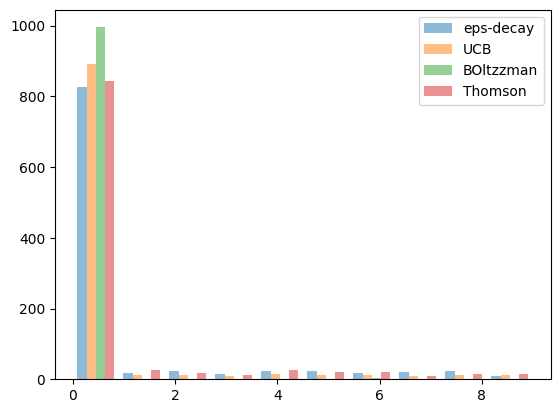

In [168]:
plt.hist([actions1, actions2, actions3, actions4], bins=10, alpha=0.5, label=['eps-decay', 'UCB', 'BOltzzman', 'Thomson'])

plt.legend()
plt.show()


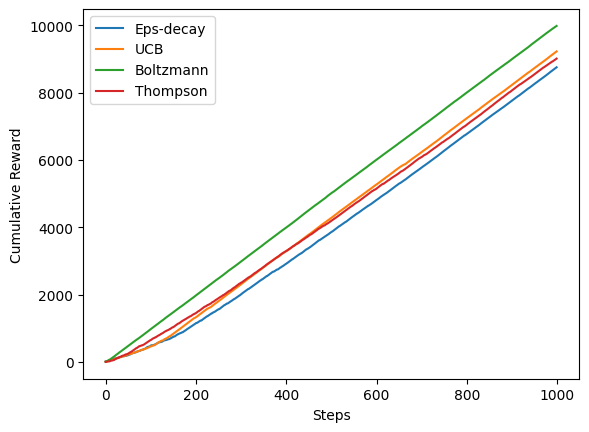

In [169]:
plt.plot(np.cumsum(rewards1), label='Eps-decay')
plt.plot(np.cumsum(rewards2), label='UCB')
plt.plot(np.cumsum(rewards3), label='Boltzmann')
plt.plot(np.cumsum(rewards4), label='Thompson')
plt.xlabel('Steps')
plt.ylabel('Cumulative Reward')
plt.legend()

In [ ]:
'''
For thomson method, we initilized var to be quited high so its not a surpise
that its exploring more
If we initialize boltman tau more it will explore more too

whereas in case of UCB it converges to arm 0 quite early, cause the benefit from
exploration wasnt that high. so it stayed at arm 0

In case of epsilon-decay the exploration was high due to high initial eps value
but then it the eps decayed to 0.1, which is fine to be fair. As in this
case the problem was quite simple only 1 arm was giving the most but if multiple
arms were also much profitable then exploration is helpful.

'''